In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
fmf = pd.read_csv('../../data/fmf.csv', index_col=0)

fmf.info()

<class 'pandas.DataFrame'>
Index: 417 entries, 0 to 420
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   post_id               417 non-null    str    
 1   post_title            417 non-null    str    
 2   time_posted           417 non-null    int64  
 3   0.5hr_score           417 non-null    float64
 4   0.5hr_ratio           417 non-null    float64
 5   0.5hr_comment         417 non-null    float64
 6   1hr_score             417 non-null    float64
 7   1hr_ratio             417 non-null    float64
 8   1hr_comment           417 non-null    float64
 9   2hr_score             417 non-null    float64
 10  2hr_ratio             417 non-null    float64
 11  2hr_comment           417 non-null    float64
 12  5hr_score             417 non-null    float64
 13  5hr_ratio             417 non-null    float64
 14  5hr_comment           417 non-null    float64
 15  24hr_score            417 non-null    f

In [52]:
fmf.sample(4)

,post_id,post_title,time_posted,0.5hr_score,0.5hr_ratio,0.5hr_comment,1hr_score,1hr_ratio,1hr_comment,2hr_score,...,2hr_comment,5hr_score,5hr_ratio,5hr_comment,24hr_score,24hr_ratio,24hr_comment,current_score,current_num_comments,current_upvote_ratio
101,1p6mi7j,"$20.68 Outdoor Research Zendo 10in Shorts, Fin...",1764100247,0.0,0.50,3.0,1.0,0.60,3.0,1.0,...,3.0,2.0,0.59,6.0,6.0,0.65,6.0,10,6,0.71
82,1p7m2to,Independence Black Friday Sale (30% Sitewide),1764197443,5.0,0.86,1.0,8.0,0.83,1.0,14.0,...,6.0,27.0,0.83,9.0,45.0,0.88,17.0,58,17,0.89
115,1p62wyr,Sportsman's Warehouse - Darn Tough Socks 25% O...,1764044051,13.0,0.93,3.0,17.0,0.95,4.0,21.0,...,10.0,26.0,0.94,12.0,68.0,0.97,24.0,79,32,0.96
74,1p8872n,Fresh Rags 40% off sitewide,1764265116,4.0,0.83,2.0,9.0,0.91,2.0,8.0,...,2.0,9.0,0.77,3.0,20.0,0.84,5.0,24,6,0.89


In [53]:
more_selftext = pd.read_csv('../../data/post_selftext.csv')

more_selftext.info()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   post_id   439 non-null    str  
 1   selftext  313 non-null    str  
dtypes: str(2)
memory usage: 7.0 KB


In [54]:
more_selftext['is_deleted'] = more_selftext['selftext'] == '[deleted]'
more_selftext['is_removed'] = more_selftext['selftext'] == '[removed]'

In [55]:
more_selftext['is_deleted'].value_counts()

is_deleted
False    429
True      10
Name: count, dtype: int64

In [56]:
more_selftext['is_removed'].value_counts()

is_removed
False    360
True      79
Name: count, dtype: int64

In [57]:
historical = pd.read_csv('../../data/historical_data.csv')

historical.info()

<class 'pandas.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       1042 non-null   str    
 1   source        1042 non-null   str    
 2   title         1042 non-null   str    
 3   selftext      763 non-null    str    
 4   created_utc   1042 non-null   float64
 5   score         1042 non-null   int64  
 6   num_comments  1042 non-null   int64  
 7   upvote_ratio  1042 non-null   float64
 8   scraped_at    1042 non-null   float64
dtypes: float64(3), int64(2), str(4)
memory usage: 73.4 KB


In [58]:
historical['source'].value_counts()

source
new    995
top     42
hot      5
Name: count, dtype: int64

In [59]:
historical[['post_id','selftext']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   post_id   1042 non-null   str  
 1   selftext  763 non-null    str  
dtypes: str(2)
memory usage: 16.4 KB


In [60]:
df = pd.merge(fmf, more_selftext, on='post_id', how='left')

In [61]:
df_model = df[['post_id','post_title','time_posted','24hr_score','selftext', 'is_deleted', 'is_removed']]

In [62]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   post_id      417 non-null    str    
 1   post_title   417 non-null    str    
 2   time_posted  417 non-null    int64  
 3   24hr_score   417 non-null    float64
 4   selftext     296 non-null    str    
 5   is_deleted   417 non-null    bool   
 6   is_removed   417 non-null    bool   
dtypes: bool(2), float64(1), int64(1), str(3)
memory usage: 17.2 KB


In [63]:
df_model['has_selftext'] = ~df_model['selftext'].isna()

In [64]:
df_model['has_selftext'].value_counts()

has_selftext
True     296
False    121
Name: count, dtype: int64

defining label / metric

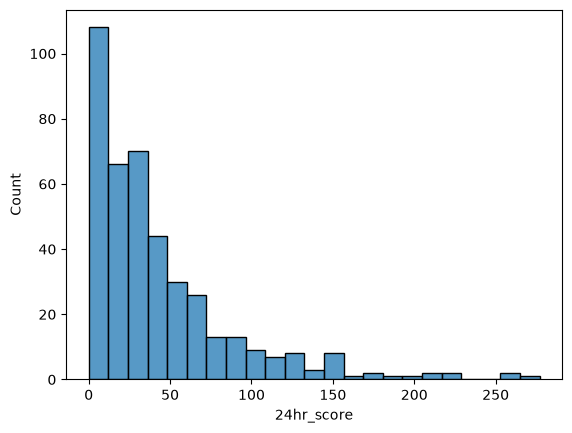

In [65]:
sns.histplot(df_model, x='24hr_score');

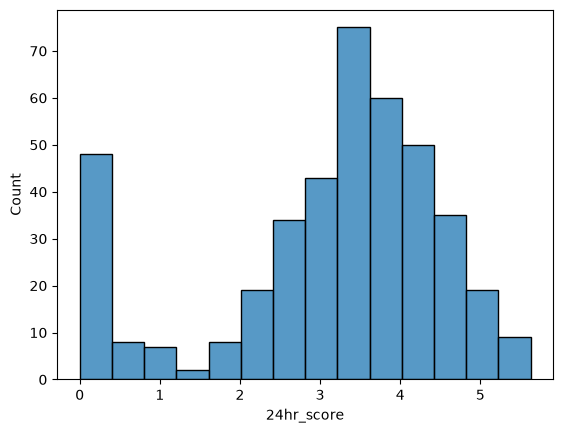

In [66]:
sns.histplot(np.log1p(df_model['24hr_score']));

In [67]:
df_model[df_model['24hr_score'] == 0]['has_selftext'].mean()

np.float64(0.8541666666666666)

In [68]:
df_model['text_length'] = df_model['selftext'].fillna('').str.len()

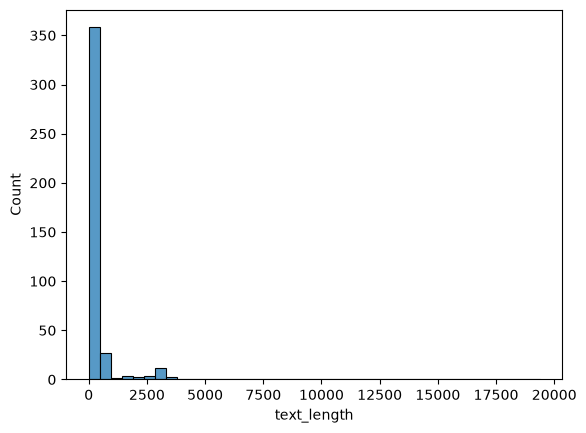

In [69]:
sns.histplot(df_model['text_length']);

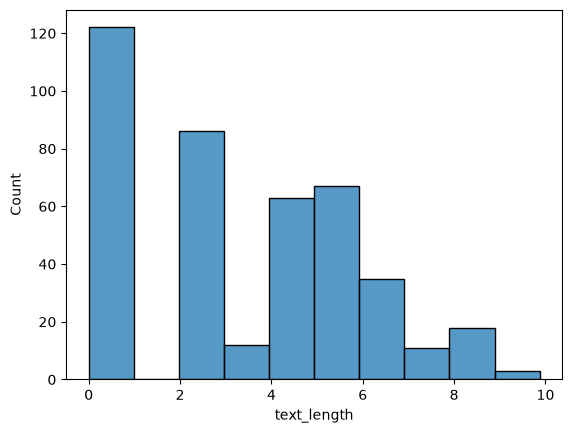

In [70]:
sns.histplot(np.log1p(df_model['text_length']));

In [71]:
df_model.groupby('has_selftext')['24hr_score'].agg(['mean', 'median', 'count'])

,mean,median,count
has_selftext,,,
False,35.710744,30.0,121
True,46.179054,31.0,296


In [72]:
df_model.groupby('is_deleted')['24hr_score'].agg(['mean', 'median', 'count'])

,mean,median,count
is_deleted,,,
False,43.982801,31.0,407
True,8.900000,1.0,10


In [73]:
df_model.groupby('is_removed')['24hr_score'].agg(['mean', 'median', 'count'])

,mean,median,count
is_removed,,,
False,48.961988,34.0,342
True,16.600000,2.0,75


 could just be due to data leakage --> post was bad, so low quality, low upvotes, hence removed / deleted

In [74]:
df_model.assign(near_zero = df_model['24hr_score'] <= 2).groupby(['is_removed','is_deleted'])['near_zero'].mean()

is_removed  is_deleted
False       False         0.054217
            True          0.600000
True        False         0.520000
Name: near_zero, dtype: float64

Baseline near-zero rate among normal posts is 5.4%, natural noise. But it jumps to 52% for removed posts and 60% for deleted posts.

decision: going to delete and exclude --> this isn't what the model shoudl be learning to predict.

In [75]:
df_clean = df_model[~(df_model['is_removed'] | df_model['is_deleted'])]

df_clean[['is_removed','is_deleted']].sum() 

is_removed    0
is_deleted    0
dtype: int64

In [76]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 332 entries, 0 to 416
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       332 non-null    str    
 1   post_title    332 non-null    str    
 2   time_posted   332 non-null    int64  
 3   24hr_score    332 non-null    float64
 4   selftext      211 non-null    str    
 5   is_deleted    332 non-null    bool   
 6   is_removed    332 non-null    bool   
 7   has_selftext  332 non-null    bool   
 8   text_length   332 non-null    int64  
dtypes: bool(3), float64(1), int64(2), str(3)
memory usage: 19.1 KB


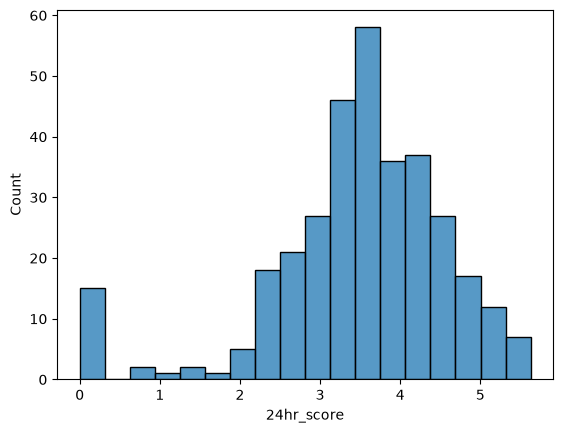

In [77]:
sns.histplot(np.log1p(df_clean['24hr_score']));

In [78]:
print(len(df_clean))

332


In [79]:
df_clean.set_index(pd.to_datetime(df_clean['time_posted'], unit='s')).resample('SME')['24hr_score'].count()

time_posted
2025-08-15      5
2025-08-31     10
2025-09-15     35
2025-09-30     40
2025-10-15     38
2025-10-31     57
2025-11-15    111
2025-11-30     36
Freq: SME-15, Name: 24hr_score, dtype: int64

In [80]:
df_clean[(df_clean['time_posted'] >= pd.Timestamp('2025-11-01').timestamp()) & 
         (df_clean['time_posted'] < pd.Timestamp('2025-11-16').timestamp())][['post_id','post_title','time_posted']].sort_values('time_posted')['post_title'].to_list()

['New Balance 990v6 - Grey - $140',
 'Trickers Factory Outlet Additional 20% off',
 'Adidas - Black Friday 2025 deals live now',
 "VRST Men's Essential Hoodie (Teal Twilight Feeder Stripe) $11.18",
 "New Balance 2002R in Tan/White for $59.47 (reg. $145) @ Dick's, 8D - 12D available",
 'The best sneaker deals of the week 🚀',
 '$122 41mm Seiko Chronograph Quartz Green Dial with code FLASHFS7',
 '$105 New Balance 990v6 in Sea Salt | MiUSA',
 'Red Wing 2nds (Beckman, IR, Mocs, oxfords, others) @ Berkeley Supply ($95-$205)',
 "Up to 50% off: Men's Outfits and Accessory Items at adidas",
 'Yema - Early Black Friday Sale- Up to 40% off on Select Watches',
 'Banana Republic Extra 40% off Full Price at Checkout',
 'Red Wing Weekender Oxford CRT size 7.5-9.5 - 30% off',
 "On Cloudflow 4 Men's Running Shoes $95",
 'Additional 50% off Sale in Cart at Gap + 18% cash back Rakuten',
 '$9.99 Joseph Abboud Linen Chino in Navy (M-XL)',
 "Wolverine Men's Work Hiker Mid Waterproof Boots $55 with code BOOT

data looks good -- nothign is duplicated or resembling an artifact

In [81]:
df_clean.groupby('has_selftext')['24hr_score'].agg(['mean', 'median', 'count'])

,mean,median,count
has_selftext,,,
False,35.710744,30.0,121
True,58.459716,40.0,211


feature engineering

In [82]:
df_clean.to_csv('../../data/df_clean.csv', index=False)

1. time

In [83]:
dt = pd.to_datetime(df_clean['time_posted'], unit = 's', utc=True)

df_clean['hour'] = dt.dt.hour
df_clean['day_of_week'] = dt.dt.dayofweek
df_clean["is_weekend"] = (df_clean["day_of_week"] >= 5).astype(int)

# cyclical encoding

df_clean["hour_sin"] = np.sin(2 * np.pi * df_clean["hour"] / 24)
df_clean["hour_cos"] = np.cos(2 * np.pi * df_clean["hour"] / 24)

df_clean["dow_sin"] = np.sin(2 * np.pi * df_clean["day_of_week"] / 7)
df_clean["dow_cos"] = np.cos(2 * np.pi * df_clean["day_of_week"] / 7)


2 title text

In [84]:
# generic
df_clean['title_len'] = df_clean['post_title'].str.len()
df_clean['title_word_count'] = df_clean['post_title'].str.split().str.len()
df_clean['title_punct_count'] = df_clean['post_title'].str.count(r"[^\w\s]")

# domain
df_clean['has_dollar'] = df_clean['post_title'].str.contains(r"\$", regex=True)
df_clean['has_percent'] = df_clean['post_title'].str.contains(r"%", regex=True)
df_clean['has_code'] = df_clean['post_title'].str.contains(r"\bcode\b", case=False, regex=True)

In [85]:
#checking
df_clean[df_clean['has_dollar']].sample(3)['post_title']

213                   Barbour Bedale black 44-48 $165.93
344    New Balance 2002R - Tan/White - $69.97 at Dick...
32             Brooks Brothers 40% Off - MiUSA OCBD <$90
Name: post_title, dtype: str

In [86]:
df_clean[df_clean['has_percent']].sample(3)['post_title']

333             RVCA Sale - Up to 50% off
65     J. Crew 60% off on clearance sale!
74            Fresh Rags 40% off sitewide
Name: post_title, dtype: str

In [87]:
df_clean[df_clean['has_code']].sample(3)['post_title']

337    J.Crew: Extra 60% Off Sale Items w/ Code BIGSA...
374    Bronson MFG - 14% off plus free shipping over ...
49        Merrell now has an extra 40% with code EXTRA40
Name: post_title, dtype: str

In [88]:
df_clean['log_score'] = np.log1p(df_clean['24hr_score'])

In [89]:
def evaluate_flag(df_clean, flag_col, target="log_score"):
    grouped = df_clean.groupby(flag_col)[target]

    stats = grouped.agg(["count", "mean", "median", "std"])
    print(f"\n=== {flag_col} ===")
    print(stats)

    diff = stats.loc[True, "mean"] - stats.loc[False, "mean"]
    print(f"Mean difference: {diff:.4f}")

In [90]:
from scipy.stats import mannwhitneyu

def test_significance(df_clean, flag_col, target="log_score"):
    group1 = df_clean[df_clean[flag_col]][target]
    group0 = df_clean[~df_clean[flag_col]][target]

    stat, p = mannwhitneyu(group1, group0, alternative="two-sided")
    print(f"{flag_col}: p-value = {p:.6f}")

In [91]:
for col in ["has_dollar", "has_percent", "has_code"]:
    evaluate_flag(df_clean, col)
    test_significance(df_clean, col)


=== has_dollar ===
            count      mean    median       std
has_dollar                                     
False         185  3.663119  3.663562  0.989483
True          147  3.250024  3.496508  1.240526
Mean difference: -0.4131
has_dollar: p-value = 0.002958

=== has_percent ===
             count      mean    median       std
has_percent                                     
False          179  3.399673  3.583519  1.287838
True           153  3.574438  3.555348  0.892479
Mean difference: 0.1748
has_percent: p-value = 0.514632

=== has_code ===
          count      mean    median       std
has_code                                     
False       291  3.474052  3.583519  1.132783
True         41  3.523933  3.555348  1.079257
Mean difference: 0.0499
has_code: p-value = 0.870212


3. selftext

In [92]:
df_clean["selftext_length_check"] = (
    df_clean["selftext"]
    .fillna("")
    .str.len()
)

In [93]:
(df_clean["text_length"] == df_clean["selftext_length_check"]).all()

np.True_

In [94]:
df_clean = df_clean.drop(columns='selftext_length_check')

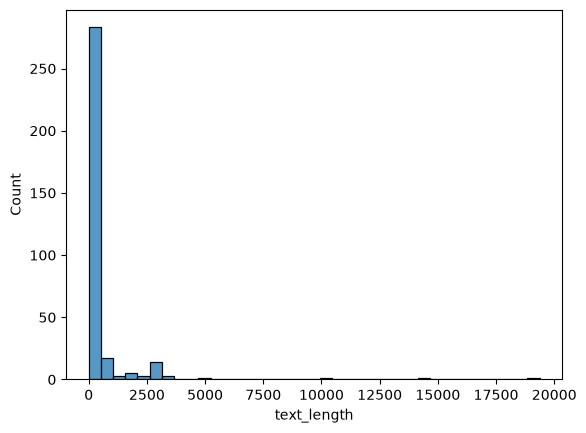

In [95]:
sns.histplot(df_clean['text_length']);

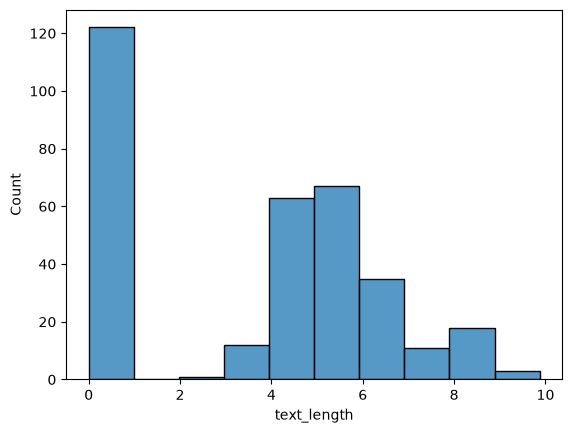

In [96]:
sns.histplot(np.log1p(df_clean['text_length']));

In [97]:
df_clean["log_text_length"] = np.log1p(
    df_clean["text_length"]
)

df_clean.groupby("has_selftext")["log_score"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
has_selftext,,,,
False,121,3.182073,3.433987,1.108964
True,211,3.651183,3.713572,1.100452


In [98]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 332 entries, 0 to 416
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   post_id            332 non-null    str    
 1   post_title         332 non-null    str    
 2   time_posted        332 non-null    int64  
 3   24hr_score         332 non-null    float64
 4   selftext           211 non-null    str    
 5   is_deleted         332 non-null    bool   
 6   is_removed         332 non-null    bool   
 7   has_selftext       332 non-null    bool   
 8   text_length        332 non-null    int64  
 9   hour               332 non-null    int32  
 10  day_of_week        332 non-null    int32  
 11  is_weekend         332 non-null    int64  
 12  hour_sin           332 non-null    float64
 13  hour_cos           332 non-null    float64
 14  dow_sin            332 non-null    float64
 15  dow_cos            332 non-null    float64
 16  title_len          332 non-null    int64  

In [ ]:
df_clean['is_weekend'].sum() / len(df_clean) # ~ 1.58 / 7 days

np.float64(0.22590361445783133)

In [105]:
df_clean = df_clean.drop(columns = ['is_deleted', 'is_removed']) # this was used to remove low quality posts

df_clean['selftext'] = df_clean['selftext'].fillna('')

df_clean = df_clean.sort_values('time_posted').reset_index(drop=True)